#  Importing and loading libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
import time
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC
import xgboost as xgb

from imblearn.under_sampling import RandomUnderSampler
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)
from statsmodels.stats.outliers_influence import variance_inflation_factor
from imblearn.over_sampling import SMOTE
import joblib
# display all floating-point numbers in DataFrames (pandas by default showing the large floating number to imaginary)
pd.set_option('display.float_format', '{:.4f}'.format)

# Step 1: Load & Label NFStream CSVs

Load the attack and normal CSVs, add binary labels, combine.

In [ ]:
#importing attack dataset and labeling it
attack_df = pd.read_csv('nfstream_attack.csv',low_memory=False)
attack_df['label'] = 'attack'

#importing normal dataset and labeling it
normal_df = pd.read_csv('nfstream_normal.csv',low_memory=False)
normal_df['label'] = 'normal'

# combining normal and attack csv into one dataset
final_df = pd.concat([attack_df, normal_df], ignore_index=True)
final_df.to_csv('finalDatasetCombnation.csv', index=False)
print(f'Combined data shape: {final_df.shape}')
print('Label distribution:')
print(final_df['label'].value_counts())

Combined data shape: (231688, 88)
Label distribution:
label
normal    122490
attack    109198
Name: count, dtype: int64


# Step 2: Exploratory Data Analysis

In [ ]:
#importing the combined csv
df = pd.read_csv('finalDatasetCombnation.csv', low_memory=False)


print('-'*54)
print('         Dataset Summary')
print('-'*54)
print('Dataset Shape: ', df.shape)

#printing the first 5 rows
print("first 5 rows: ",df.head())

#printing the last 5 rows
print("last 5 rows:",df.tail())

#listing column names, data types, and identifying missing (null) values
print("dataset Info :")
df.info()

# Summarizes numeric data by showing the average, the range (min to max), and how spread out the values are to help spot weird outliers
print("Statistical Distribution: ", df.describe())

# checking the distribution of each label. ensuring if the labels are balanced or not
print('Label distribution:')
print(df['label'].value_counts())

------------------------------------------------------
         Dataset Summary
------------------------------------------------------
Dataset Shape:  (231688, 88)
first 5 rows:     id  expiration_id         src_ip            src_mac  src_oui  src_port  \
0   0              0  192.168.75.20  08:00:27:27:f1:85  8:00:27      3389   
1   1              0  192.168.75.10  08:00:27:f5:46:5a  8:00:27     33679   
2   2              0  192.168.75.10  08:00:27:f5:46:5a  8:00:27     41591   
3   3              0  192.168.75.10  08:00:27:f5:46:5a  8:00:27     56564   
4   4              0  192.168.75.10  08:00:27:f5:46:5a  8:00:27     56576   

          dst_ip            dst_mac  dst_oui  dst_port  ...  \
0  192.168.75.10  08:00:27:f5:46:5a  8:00:27     45835  ...   
1  192.168.75.20  08:00:27:27:f1:85  8:00:27      3389  ...   
2  192.168.75.20  08:00:27:27:f1:85  8:00:27      3389  ...   
3  192.168.75.20  08:00:27:27:f1:85  8:00:27      3389  ...   
4  192.168.75.20  08:00:27:27:f1:85  8:00:2

# Step3: DataCleaning

In this step,


1.   We replaced infint values with Nan value to ensure because most machine learning algorithms cannot perform well in calculations with infinity values , leading to system crashes or "broken" models
2.   Filling missing values (nan) with the median, replaces empty cells with the middle value of the column, providing a stable estimate that prevents extreme outliers from distorting the data.
3. we Fixed label inconsistencies like whitespaces and diffrent formatting style to ensure labels are in the same standard
4.  Drop duplicated without it the models going to be Biased
5.  Removing Zero Variance features because those contains the exact same value for every row, as they provide no useful information for a model to learn from

NFStream string metadata columns (`src_mac`, `dst_mac`, `application_name`, `source_file`, etc.) are automatically dropped in Step 4 (leakage removal).

In [ ]:
df = pd.read_csv('finalDatasetCombnation.csv', low_memory=False)

# Selecting categorical features and numrical features to use it later
numerical_columns = df.select_dtypes(include=[np.number]).columns
categorical_columns = df.select_dtypes(include=['object']).columns

# ---------------------------------------------------------------------------
# Step 1: Replacing inf with nan
# ---------------------------------------------------------------------------
inf_count = np.isinf(df[numerical_columns]).sum().sum()
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# ---------------------------------------------------------------------------
# Step 2: handling missing values with median
# ---------------------------------------------------------------------------
before_nan = df.isna().sum().sum()
df.fillna(df.median(numeric_only=True), inplace=True)
# ---------------------------------------------------------------------------
# Step 3: drops columns that are more than 50% empty
# ---------------------------------------------------------------------------
threshold = 0.5 * len(df)
df = df.dropna(thresh=threshold, axis=1)
missing_features_count = df[df.columns[df.isna().any()].tolist()].isna().sum() # counting missing values after drop

# ---------------------------------------------------------------------------
# Step 4: Fix label inconsistencies (whitespaces)
# ---------------------------------------------------------------------------
df['label'] = df['label'].astype(str).str.strip().str.lower()

# ---------------------------------------------------------------------------
# Step 4: Drop duplicated
# ---------------------------------------------------------------------------
print('Before DROP duplicates:', df.shape)
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
# ---------------------------------------------------------------------------
# Step 5: Removing zero variance columns
# ---------------------------------------------------------------------------
num_cols = df.select_dtypes(include=[np.number]).columns
zero_var = df[num_cols].columns[df[num_cols].var() == 0].tolist()
zero_var_before = len(df.columns)
df = df.drop(columns=zero_var)

print('-'*54)
print('       Dataset Cleaning Summary')
print('-'*54)
print('After DROP duplicates:', df.shape)
print(f'  Inf values replaced   : {inf_count}')
print(f'  Missing after fill    : {df.isna().sum().sum()}, Before: {before_nan}')
print(f'  Zero-variance removed : {zero_var}')
print(f'  Final column count    : {len(df.columns)}')
print('-'*54)
df.to_csv('df_cleaned.csv', index=False)

Before DROP duplicates: (231688, 83)
------------------------------------------------------
       Dataset Cleaning Summary
------------------------------------------------------
After DROP duplicates: (231688, 79)
  Inf values replaced   : 0
  Missing after fill    : 0, Before: 1070781
  Zero-variance removed : ['vlan_id', 'tunnel_id', 'dst2src_cwr_packets', 'dst2src_urg_packets']
  Final column count    : 79
------------------------------------------------------


# Step 4: Feature Engineering


in this step we clean the dataset by removing leakage identifiers like (`src_ip`, `dst_ip`, `src_mac`, `dst_mac`, `src_oui`, `dst_oui`, `src_port`, `dst_port`,
all `*_first_seen_ms` / `*_last_seen_ms` timestamps, `id`, `expiration_id`, `vlan_id`, `tunnel_id`,
`protocol`, `ip_version`, `application_name`, `application_category_name`,
`application_is_guessed`, `application_confidence`, `requested_server_name`,
`client_fingerprint`, `server_fingerprint`, `user_agent`, `content_type`, `source_file`), filtering out redundant features using correlation and VIF (Variance Inflation Factor) to ensure statistical independence, and encoding text labels into numbers for the model using label encoder.




In [ ]:
df = pd.read_csv('df_cleaned.csv',low_memory=False)
y = df['label']
X = df.drop('label', axis=1)
original_features = X.shape[1]

# ---------------------------------------------------------------------------
# Step 1: Drop leakage / identifier / metadata columns (NFStream-specific)
# ---------------------------------------------------------------------------
LEAKAGE_COLS = [
    # Host identifiers
    'src_ip', 'dst_ip', 'src_mac', 'dst_mac', 'src_oui', 'dst_oui',
    # Ports
    'src_port', 'dst_port',
    # Timestamps
    'bidirectional_first_seen_ms', 'bidirectional_last_seen_ms',
    'src2dst_first_seen_ms', 'src2dst_last_seen_ms',
    'dst2src_first_seen_ms', 'dst2src_last_seen_ms',
    # Flow metadata / IDs
    'id', 'expiration_id', 'vlan_id', 'tunnel_id',
    # Protocol info (comment out if you want these as features)
    'protocol', 'ip_version',
    # DPI / application-layer strings
    'application_name', 'application_category_name',
    'application_is_guessed', 'application_confidence',
    'requested_server_name', 'client_fingerprint',
    'server_fingerprint', 'user_agent', 'content_type',
    'source_file'
]
X = X.drop(columns=[c for c in LEAKAGE_COLS if c in X.columns])
print(f'After leakage drop: {X.shape[1]} features')

# ---------------------------------------------------------------------------
# Step 2: Remove highly correlated features (r > 0.95)
# ---------------------------------------------------------------------------
numeric_X = X.select_dtypes(include=[np.number])
corr_matrix = numeric_X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
CORR_THRESHOLD = 0.95
to_drop = [col for col in upper.columns if any(upper[col] > CORR_THRESHOLD)]
X = X.drop(columns=to_drop)
remain_corr_len = X.shape[1]
print(f'After correlation filter: {remain_corr_len} features (removed {len(to_drop)})')

# ---------------------------------------------------------------------------
# Step 3: Remove Features with High VIF (VIF > 10)
# ---------------------------------------------------------------------------
print('Starting VIF feature removal loop...')
while True:
    numeric_cols = X.select_dtypes(include=[np.number]).columns
    X_vif = X[numeric_cols].astype(float)
    vif_data = pd.DataFrame({
        'feature': numeric_cols,
        'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(len(numeric_cols))]
    })
    if vif_data['VIF'].max() <= 10:
        break
    worst = vif_data.loc[vif_data['VIF'].idxmax(), 'feature']
    print(f'Removing: {worst} (VIF={vif_data["VIF"].max():.2f}) | {X.shape[1]-1} left')
    X = X.drop(columns=[worst])

# ---------------------------------------------------------------------------
# Step 4: encoding using label encoder
# ---------------------------------------------------------------------------
encoder = LabelEncoder()
y = encoder.fit_transform(y)
Class_names = encoder.classes_

print('-'*54)
print('         Feature Engineering Summary')
print('-'*54)
print(f'  Original features           : {original_features}')
print(f'  Correlated removed          : {len(to_drop)}, remaining: {remain_corr_len}')
print(f'  Final features after VIF    : {X.shape[1]}')
print('-'*54)
print('Remaining features:', X.columns.tolist())

After leakage drop: 55 features
After correlation filter: 31 features (removed 24)
Starting VIF feature removal loop...


/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Removing: bidirectional_syn_packets (VIF=inf) | 30 left


/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Removing: bidirectional_rst_packets (VIF=inf) | 29 left
Removing: bidirectional_stddev_ps (VIF=429.67) | 28 left
Removing: src2dst_mean_piat_ms (VIF=290.46) | 27 left
Removing: bidirectional_stddev_piat_ms (VIF=215.61) | 26 left
Removing: src2dst_mean_ps (VIF=126.75) | 25 left
Removing: src2dst_min_piat_ms (VIF=111.26) | 24 left
Removing: bidirectional_mean_ps (VIF=58.66) | 23 left
Removing: src2dst_stddev_piat_ms (VIF=37.32) | 22 left
Removing: dst2src_mean_piat_ms (VIF=23.41) | 21 left
Removing: bidirectional_mean_piat_ms (VIF=14.48) | 20 left
Removing: bidirectional_max_ps (VIF=14.42) | 19 left
------------------------------------------------------
         Feature Engineering Summary
------------------------------------------------------
  Original features           : 78
  Correlated removed          : 24, remaining: 31
  Final features after VIF    : 19
------------------------------------------------------
Remaining features: ['bidirectional_duration_ms', 'bidirectional_packets'

# Train/Test Split

In [ ]:
#splitting dataset into two sets. train set (to train the model) and test set (to test the model's prediction)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y, shuffle=True)
print(f'Training set: {X_train.shape} | Test set: {X_test.shape}')

Training set: (185350, 19) | Test set: (46338, 19)


#Scaling/Normalizing using RobustScaler

We have selected Robust scaler to scale only numaric columns. due to it's streangth to handle outliers. which our dataset have.




In [ ]:
# fit only on training set and trasforming for testing set
numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
scaler = RobustScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols]  = scaler.transform(X_test[numeric_cols])
print(f'Training set shape: {X_train.shape} | Test set shape: {X_test.shape}')

Training set shape: (185350, 19) | Test set shape: (46338, 19)


# Treating imbalanced classes Using SMOTE (oversampling)

In [ ]:
# fitting on training set only
re = SMOTE(random_state=42)
X_train, y_train = re.fit_resample(X_train, y_train)
print(f'After Oversampling | Training set: {X_train.shape}')
print(np.unique(y_train, return_counts=True))

After Oversampling | Training set: (195984, 19)
(array([0, 1]), array([97992, 97992]))


# Feature Importance (Random Forest)
*   there is alot of techniques to show the importance of each feature (the power of each feature that helps model to predict)
*   we use Random Forest model thats already have integrated feature importance

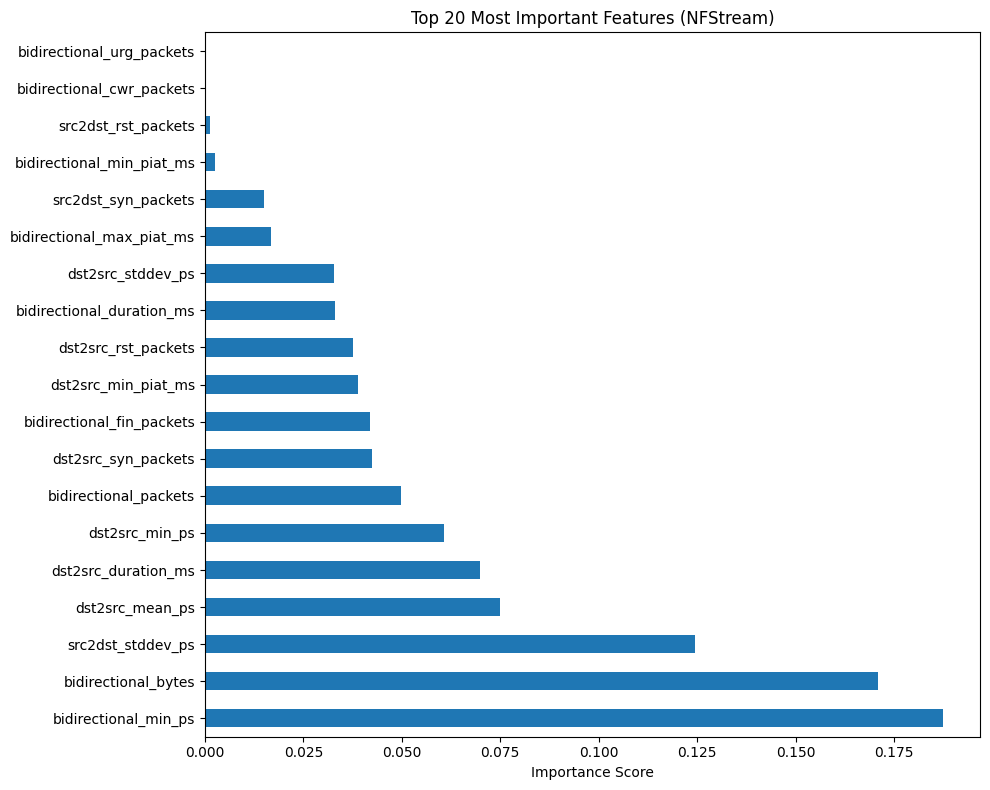

bidirectional_min_ps        0.1874
bidirectional_bytes         0.1709
src2dst_stddev_ps           0.1244
dst2src_mean_ps             0.0749
dst2src_duration_ms         0.0699
dst2src_min_ps              0.0606
bidirectional_packets       0.0498
dst2src_syn_packets         0.0423
bidirectional_fin_packets   0.0420
dst2src_min_piat_ms         0.0389
dst2src_rst_packets         0.0377
bidirectional_duration_ms   0.0330
dst2src_stddev_ps           0.0328
bidirectional_max_piat_ms   0.0167
src2dst_syn_packets         0.0150
bidirectional_min_piat_ms   0.0025
src2dst_rst_packets         0.0013
bidirectional_cwr_packets   0.0000
bidirectional_urg_packets   0.0000
dtype: float64


In [ ]:
#training the model on training set to show the importance of each feature to the model
feature_cols = X_train.columns.tolist()
dt = RandomForestClassifier(random_state=42, class_weight='balanced')
dt.fit(X_train, y_train)

#storing the important features in pandas series to plot it
importances = pd.Series(dt.feature_importances_, index=feature_cols).sort_values(ascending=False)

#plotting the important features
plt.figure(figsize=(10, 8))
importances.head(20).plot(kind='barh')
plt.title('Top 20 Most Important Features (NFStream)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

#prining the importance to know exactly the number of importnace of each feature0
print(importances)

# Feature Selection (Top N)
selecting important/useful features for models based on feature importnace, then saving selected features to json file for IDS usage


In [ ]:
TOP_N = 19
top_features = importances.head(TOP_N).index.tolist()
print(f'Selected {TOP_N} features:')
for i, f in enumerate(top_features, 1):
    print(f'  {i}. {f}')

X_train_selected = X_train[top_features]
X_test_selected  = X_test[top_features]

with open('selected_features.json', 'w') as f:
    json.dump(top_features, f)
print('Saved selected_features.json')

Selected 19 features:
  1. bidirectional_min_ps
  2. bidirectional_bytes
  3. src2dst_stddev_ps
  4. dst2src_mean_ps
  5. dst2src_duration_ms
  6. dst2src_min_ps
  7. bidirectional_packets
  8. dst2src_syn_packets
  9. bidirectional_fin_packets
  10. dst2src_min_piat_ms
  11. dst2src_rst_packets
  12. bidirectional_duration_ms
  13. dst2src_stddev_ps
  14. bidirectional_max_piat_ms
  15. src2dst_syn_packets
  16. bidirectional_min_piat_ms
  17. src2dst_rst_packets
  18. bidirectional_cwr_packets
  19. bidirectional_urg_packets
Saved selected_features.json


# Model Definitions
we defined the models with thier parameter to train them later

In [ ]:
models = {
    "RandomForest": RandomForestClassifier(n_estimators=200, max_depth=8, min_samples_leaf=5, n_jobs=-1, random_state=42),
    "Logistic Regression": LogisticRegression(solver="saga", C=0.1, random_state=42),
    "SVM": LinearSVC(C=0.1, max_iter=10000, dual=False, random_state=42),
    "XGBoost": xgb.XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                                  random_state=42, n_jobs=-1, eval_metric='logloss'),
    "KNN": KNeighborsClassifier(n_neighbors=25, weights="distance", n_jobs=-1)
}

# Training & Evaluation


  Model: RandomForest
              precision    recall  f1-score   support

      attack       1.00      1.00      1.00     21840
      normal       1.00      1.00      1.00     24498

    accuracy                           1.00     46338
   macro avg       1.00      1.00      1.00     46338
weighted avg       1.00      1.00      1.00     46338

  Accuracy  : 0.9984
  Precision : 0.9984
  Recall    : 0.9984
  F1-Score  : 0.9984
  CV Mean   : 0.9983  |  CV Std: 0.0001


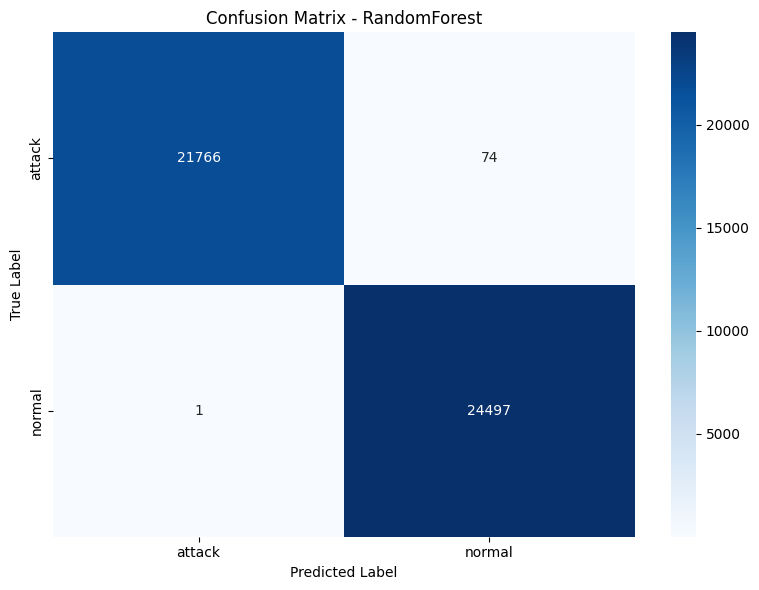

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which 

  Model: Logistic Regression
              precision    recall  f1-score   support

      attack       0.43      0.44      0.44     21840
      normal       0.49      0.49      0.49     24498

    accuracy                           0.47     46338
   macro avg       0.46      0.46      0.46     46338
weighted avg       0.47      0.47      0.47     46338

  Accuracy  : 0.4657
  Precision : 0.4661
  Recall    : 0.4657
  F1-Score  : 0.4659
  CV Mean   : 0.4649  |  CV Std: 0.0013


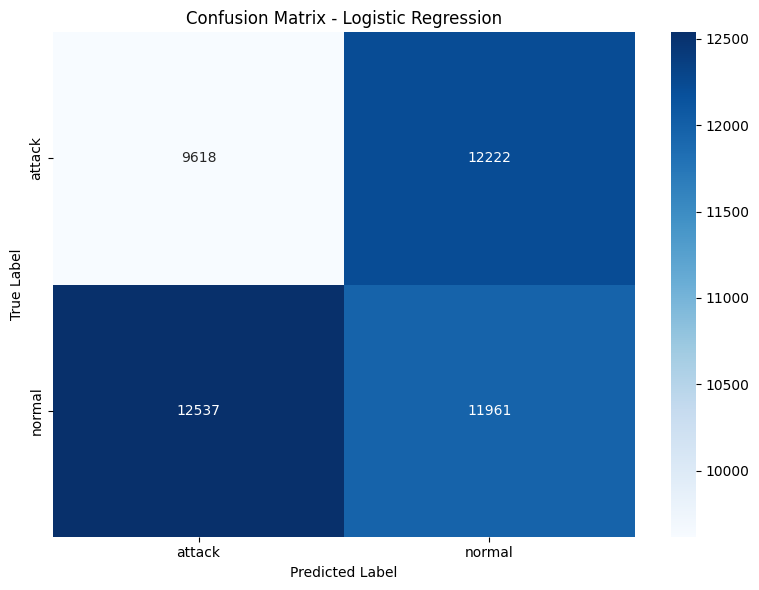

  Model: SVM
              precision    recall  f1-score   support

      attack       0.89      0.82      0.85     21840
      normal       0.85      0.91      0.88     24498

    accuracy                           0.87     46338
   macro avg       0.87      0.86      0.87     46338
weighted avg       0.87      0.87      0.87     46338

  Accuracy  : 0.8670
  Precision : 0.8686
  Recall    : 0.8670
  F1-Score  : 0.8665
  CV Mean   : 0.8629  |  CV Std: 0.0009


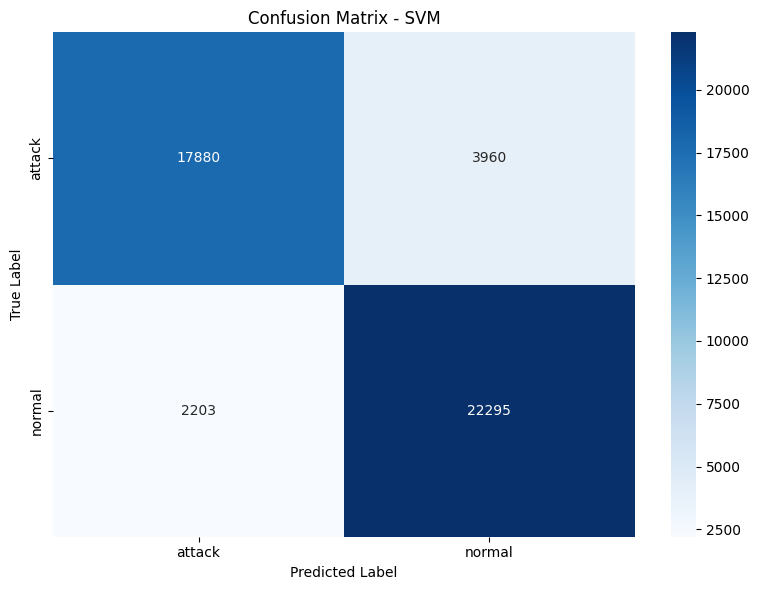

  Model: XGBoost
              precision    recall  f1-score   support

      attack       1.00      1.00      1.00     21840
      normal       1.00      1.00      1.00     24498

    accuracy                           1.00     46338
   macro avg       1.00      1.00      1.00     46338
weighted avg       1.00      1.00      1.00     46338

  Accuracy  : 0.9987
  Precision : 0.9987
  Recall    : 0.9987
  F1-Score  : 0.9987
  CV Mean   : 0.9986  |  CV Std: 0.0002


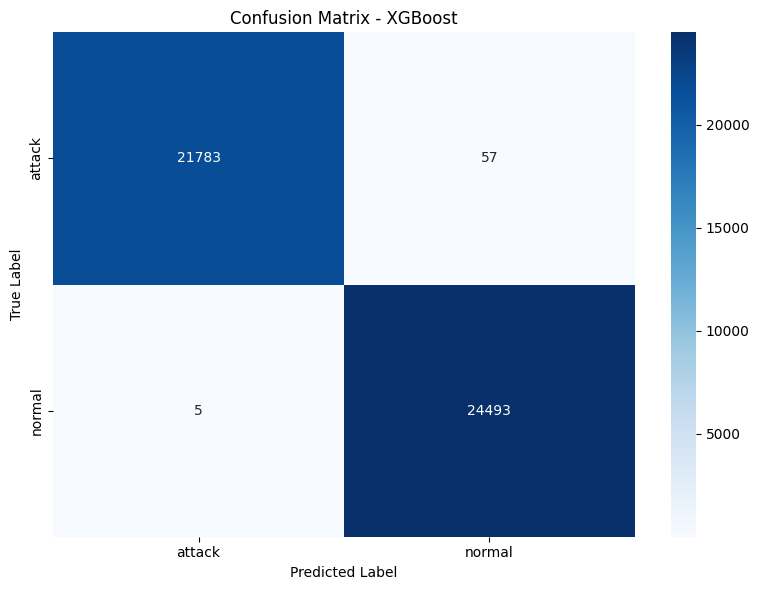

  Model: KNN
              precision    recall  f1-score   support

      attack       1.00      1.00      1.00     21840
      normal       1.00      1.00      1.00     24498

    accuracy                           1.00     46338
   macro avg       1.00      1.00      1.00     46338
weighted avg       1.00      1.00      1.00     46338

  Accuracy  : 0.9982
  Precision : 0.9982
  Recall    : 0.9982
  F1-Score  : 0.9982
  CV Mean   : 0.9981  |  CV Std: 0.0003


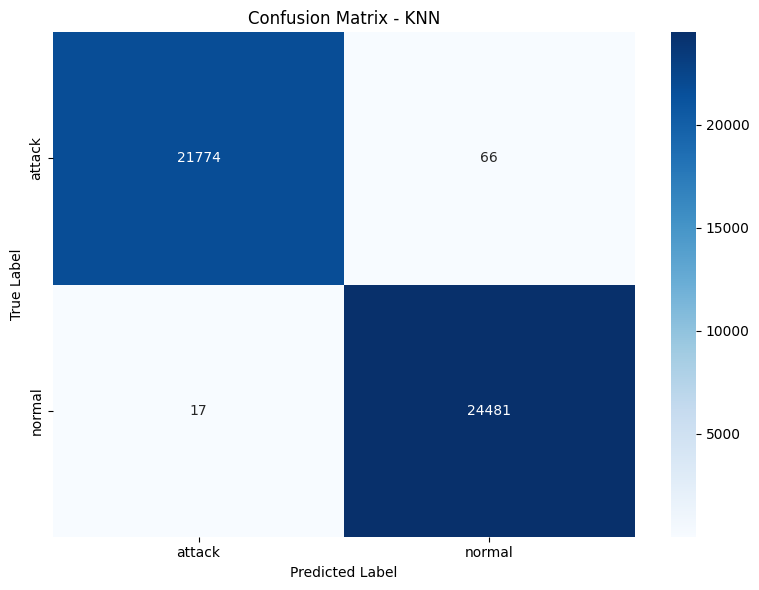

In [ ]:
import tracemalloc
results = {}
timing_results = {}

for model_name, model in models.items():
    # --- START MEMORY TRACKING ---
    tracemalloc.start()

    # 1. Start timer and train the model
    start_train = time.time()
    model.fit(X_train_selected, y_train) #training the model
    train_time = time.time() - start_train

    # --- GET PEAK MEMORY & STOP TRACKING ---
    current, peak = tracemalloc.get_traced_memory()
    peak_mem_mb = peak / (1024 * 1024)
    tracemalloc.stop()

    # 2. Time how long the model takes to make predictions
    start_prediction = time.time()
    y_pred = model.predict(X_test_selected) #predicing the model
    predict_time = time.time() - start_prediction

    # 3. Perform 5-fold cross-validation
    cv_scores = cross_val_score(model, X_train_selected, y_train, cv=5)

    # 4. Calculate core performance metrics
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    # Store evaluation metrics
    results[model_name] = {'Accuracy': acc, 'Precision': prec,
                           'Recall': rec, 'F1-Score': f1,
                           'CV Mean': cv_scores.mean(), 'CV Std': cv_scores.std()}

    # Store efficiency metrics
    timing_results[model_name] = {
        'Training Time (s)': round(train_time, 4),
        'Prediction Time (s)': round(predict_time, 4),
        'Peak Memory (MB)': round(peak_mem_mb, 2)
    }

    # 6. Print a detailed classification report for each class
    print('='*60)
    print(f'  Model: {model_name}')
    print('='*60)
    print(classification_report(y_test, y_pred, target_names=encoder.classes_, zero_division=0))
    print(f'  Accuracy  : {acc:.4f}')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'  F1-Score  : {f1:.4f}')
    print(f'  CV Mean   : {cv_scores.mean():.4f}  |  CV Std: {cv_scores.std():.4f}')

    # 7. Generate, display, and save a Heatmap of the Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=encoder.classes_, yticklabels=encoder.classes_)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('True Label'); plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(f'confusion_matrix_{model_name.replace(" ", "_")}.png', dpi=150)
    plt.show()

# Stop the tracker after the loop is done
tracemalloc.stop()

#Computational Efficiency Comparison

---



       Computational Efficiency Comparison
                     Training Time (s)  Prediction Time (s)  Peak Memory (MB)
RandomForest                   28.6052               0.2840           44.7700
Logistic Regression             8.8107               0.0042           56.8200
SVM                             7.6747               0.0044           56.8200
XGBoost                         3.0731               0.1507            1.8700
KNN                             0.0259              53.1282           56.8200


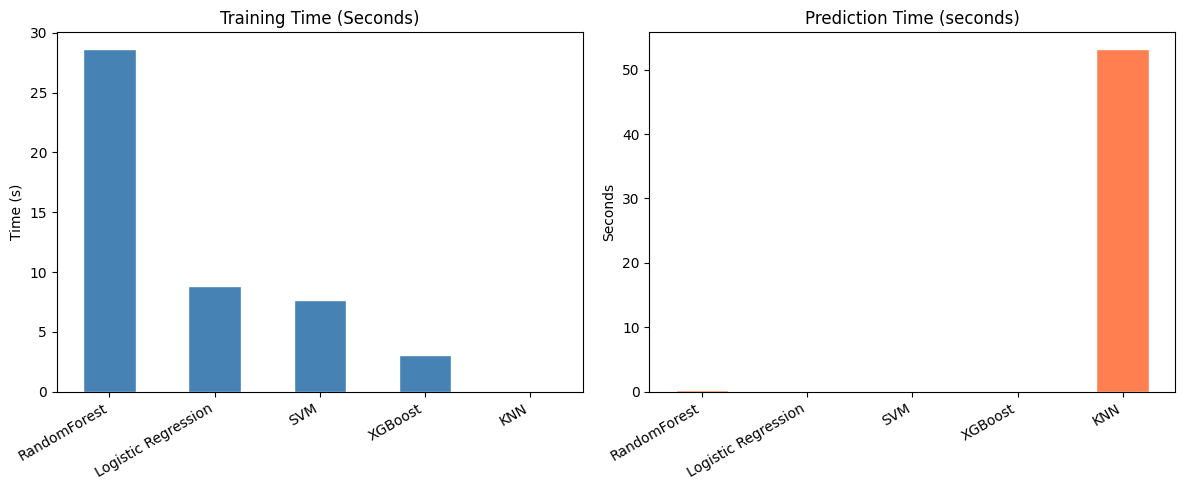

In [ ]:
# Convert timing dictionary to dataframe
timing_df = pd.DataFrame(timing_results).T
print("="*60)
print("       Computational Efficiency Comparison")
print("="*60)
print(timing_df.to_string())
print("="*60)

# Efficiency Bar charts
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Training Time
timing_df['Training Time (s)'].plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Training Time (Seconds)')
axes[0].set_ylabel('Time (s)')
axes[0].set_xticklabels(timing_df.index, rotation=30, ha='right')

# plotting Prediction time of each model to compare between them
timing_df['Prediction Time (s)'].plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Prediction Time (seconds)')
axes[1].set_ylabel('Seconds')
axes[1].set_xticklabels(timing_df.index, rotation=30, ha='right')

plt.tight_layout()
plt.savefig('timing_comparison.png', dpi=150)
plt.show()

#Selecting Best model
we select the best model based on higher F1 Score

         Model Comparison Summary
                     Accuracy  Precision  Recall  F1-Score  CV Mean  CV Std
XGBoost                0.9987     0.9987  0.9987    0.9987   0.9986  0.0002
RandomForest           0.9984     0.9984  0.9984    0.9984   0.9983  0.0001
KNN                    0.9982     0.9982  0.9982    0.9982   0.9981  0.0003
SVM                    0.8670     0.8686  0.8670    0.8665   0.8629  0.0009
Logistic Regression    0.4657     0.4661  0.4657    0.4659   0.4649  0.0013
  Best Model: XGBoost  (F1-Score = 0.9987)


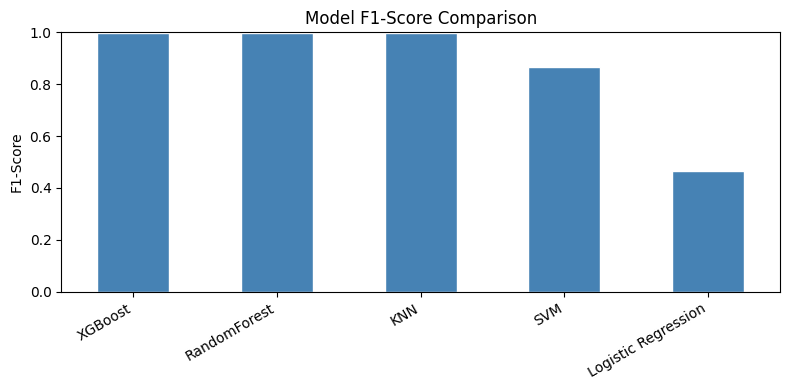

In [ ]:
summary_df = pd.DataFrame(results).T.sort_values('Accuracy', ascending=False)
print('='*60)
print('         Model Comparison Summary')
print('='*60)
print(summary_df.to_string(float_format=lambda x: f'{x:.4f}'))
print('='*60)
best = summary_df['F1-Score'].idxmax()
print(f'  Best Model: {best}  (F1-Score = {summary_df.loc[best, "F1-Score"]:.4f})')

plt.figure(figsize=(8, 4))
summary_df['F1-Score'].plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Model F1-Score Comparison')
plt.ylabel('F1-Score'); plt.xticks(rotation=30, ha='right'); plt.ylim(0, 1)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

#Generating Engineered Dataset Sample


In [ ]:
# We use X_test_selected because it hasn't been oversampled, representing real-world distribution
engineered_sample = X_test_selected.copy()
engineered_sample['label'] = encoder.inverse_transform(y_test)

# 2. Taking a sample of 1000 rows
sample = engineered_sample.sample(1000, random_state=42)

# 3. Save to CSV
sample.to_csv('engineered_dataset_sample.csv', index=False)

print("="*50)
print("      Engineered Dataset Sample Saved")
print("="*50)
print(f"File Name : engineered_dataset_sample.csv")
print(f"Rows      : {len(sample)}")
print(f"Features  : {len(sample.columns)} (including label)")

      Engineered Dataset Sample Saved
File Name : engineered_dataset_sample.csv
Rows      : 1000
Features  : 20 (including label)


# Save Best Model & Artifacts

In [ ]:
best_model = models[best]

#mapping each label with thier encoded integer value
mapping = dict(zip(Class_names, range(len(Class_names))))

with open('label_mapping.json', 'w') as f:
    json.dump(mapping, f, indent=4)

joblib.dump(best_model, 'best_model.pkl')
joblib.dump(scaler,     'scaler.pkl')
joblib.dump(encoder,    'label_encoder.pkl')

print(f'Saved: best_model.pkl   ({best})')
print('Saved: scaler.pkl')
print('Saved: label_encoder.pkl')
print('Saved: selected_features.json')
print('Saved: label_mapping.json')

Saved: best_model.pkl   (XGBoost)
Saved: scaler.pkl
Saved: label_encoder.pkl
Saved: selected_features.json
Saved: label_mapping.json
